In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# 1. Ortamın kaybolan yönünü bulması için ana dizine geçiş yapın
os.chdir('/content')

# 2. (Opsiyonel) Eğer yarım kalmış bozuk bir repo klasörü varsa temizleyin
!rm -rf /content/repo

# 3. Repoyu şimdi klonlayın (< ve > İŞARETLERİ OLMADAN)
!git clone https://github.com/irembuseozkose/qsvm-for-url-phishing /content/repo

# 4. Klonlanan dizine geçiş yapın
REPO_DIR = '/content/repo'
os.chdir(REPO_DIR)
print("📂 Çalışma dizini:", os.getcwd())

# 5. Dizin içeriğini listeleyin
!ls

Cloning into '/content/repo'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 73 (delta 24), reused 65 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 679.47 KiB | 17.88 MiB/s, done.
Resolving deltas: 100% (24/24), done.
📂 Çalışma dizini: /content/repo
guides	notebooks  readme  requirements.t  src


In [4]:
# Drive'daki veri klasörünün yolunu ayarla
# Örnek: Drive'da "MyDrive/bitirme/data/processed/" altında .npy dosyaları varsa:
DRIVE_DATA = "/content/drive/MyDrive/Ag_Guvenligi_Projesi/data/processed"  # ← kendi yolun

# Kontrol
for f in ["X_train.npy", "X_test.npy", "y_train.npy", "y_test.npy"]:
    path = os.path.join(DRIVE_DATA, f)
    assert os.path.exists(path), f"❌ Bulunamadı: {path}"
    print(f"✅ {f}")

print("\n✅ Tüm veri dosyaları mevcut.")

✅ X_train.npy
✅ X_test.npy
✅ y_train.npy
✅ y_test.npy

✅ Tüm veri dosyaları mevcut.


In [5]:
!pip install qiskit qiskit-aer pennylane -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 91.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 80.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 114.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 70.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 104.2 MB/s eta 0:00:0000:0100:01


In [6]:
import sys
sys.path.insert(0, REPO_DIR)

from src.models.quantum_kernel import QuantumKernel
from src.models.qsvm_model     import QSVM
from src.models.pso_qsvm       import PSOQSVM
from src.models.svm_model      import ClassicalSVM

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

print("✅ Modüller yüklendi.")

✅ Modüller yüklendi.


In [7]:
from sklearn.utils import resample

X_train = np.load(os.path.join(DRIVE_DATA, "X_train.npy"))
X_test  = np.load(os.path.join(DRIVE_DATA, "X_test.npy"))
y_train = np.load(os.path.join(DRIVE_DATA, "y_train.npy"))
y_test  = np.load(os.path.join(DRIVE_DATA, "y_test.npy"))

X_all_full = np.concatenate([X_train, X_test], axis=0)
y_all_full = np.concatenate([y_train, y_test], axis=0)

print(f"Tam veri: {X_all_full.shape}")

# ──────────────────────────────────
# Stratified alt örnekleme
# Her sınıftan 2500 → toplamda 10.000 örnek
# Kernel matrisi: 6666 x 6666 ≈ 350 MB (rahatça sığar)
# ──────────────────────────────────
N_PER_CLASS  = 2500
N_COMPONENTS = 15

indices = []
for cls in np.unique(y_all_full):
    cls_idx = np.where(y_all_full == cls)[0]
    sampled = resample(cls_idx, n_samples=N_PER_CLASS, 
                       replace=False, random_state=42)
    indices.append(sampled)

indices = np.concatenate(indices)
np.random.seed(42)
np.random.shuffle(indices)

X_all_raw = X_all_full[indices]
y_all     = y_all_full[indices]

print(f"Alt örneklem    : {X_all_raw.shape}")
print(f"PCA bileşen     : {N_COMPONENTS} → {int(np.ceil(np.log2(N_COMPONENTS)))} qubit")
print(f"Sınıf dağılımı  : {dict(zip(*np.unique(y_all, return_counts=True)))}")

# RAM tahmini
n_train = int(len(y_all) * 2/3)  # 3-fold'da train boyutu
ram_gb  = (n_train * n_train * 8) / (1024**3)
print(f"\nKernel matrisi  : {n_train:,} x {n_train:,} ≈ {ram_gb:.2f} GB RAM")

Tam veri: (100000, 21)
Alt örneklem    : (10000, 21)
PCA bileşen     : 15 → 4 qubit
Sınıf dağılımı  : {np.int64(0): np.int64(2500), np.int64(1): np.int64(2500), np.int64(2): np.int64(2500), np.int64(3): np.int64(2500)}

Kernel matrisi  : 6,666 x 6,666 ≈ 0.33 GB RAM


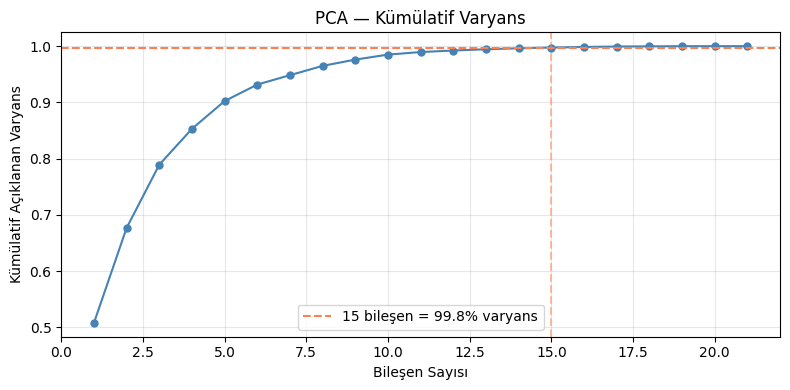

In [8]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42).fit(X_all_raw)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, "o-", color="steelblue", markersize=5)
ax.axhline(y=cumvar[N_COMPONENTS-1], color="coral", linestyle="--",
           label=f"{N_COMPONENTS} bileşen = {cumvar[N_COMPONENTS-1]*100:.1f}% varyans")
ax.axvline(x=N_COMPONENTS, color="coral", linestyle="--", alpha=0.5)
ax.set_xlabel("Bileşen Sayısı")
ax.set_ylabel("Kümülatif Açıklanan Varyans")
ax.set_title("PCA — Kümülatif Varyans")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1"       : f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

print("✅ compute_metrics tanımlandı.")

✅ compute_metrics tanımlandı.


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, normalize

def preprocess_fold(X_tr_raw, X_te_raw, n_components=8):
    """
    PCA ve scaler sadece train fold'a fit edilir,
    test fold'a sadece transform uygulanır → sızıntı yok.
    """
    # 1) PCA — sadece train'e fit
    pca = PCA(n_components=n_components, whiten=True, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr_raw)
    X_te_pca = pca.transform(X_te_raw)       # ← fit yok, sadece transform

    # 2) MinMax — sadece train'e fit
    scaler = MinMaxScaler()
    X_tr_sc = scaler.fit_transform(X_tr_pca)
    X_te_sc = scaler.transform(X_te_pca)     # ← fit yok, sadece transform

    # 3) L2 normalize (satır bazlı, sızıntı riski yok)
    X_tr_final = normalize(X_tr_sc, norm='l2')
    X_te_final = normalize(X_te_sc, norm='l2')

    return X_tr_final, X_te_final

print("✅ preprocess_fold tanımlandı — sızıntısız preprocessing.")

✅ preprocess_fold tanımlandı — sızıntısız preprocessing.


In [11]:
import time
from sklearn.model_selection import KFold

# --- 1. EKSİK OLABİLECEK DEĞİŞKENLERİ KONTROL EDİN ---
# Eğer bu değişkenler zaten üst hücrelerde tanımlıysa bu 3 satırı silebilirsiniz.
# Ancak tanımlı değilse kod yine hata verir, bu yüzden emin olmak için ekliyorum:
N_SPLITS = 5
N_COMPONENTS = 15 # PCA vs. kullanıyorsanız boyut sayısı
# X_all_raw ve y_all verilerinizin zaten tanımlı ve hazır olduğunu varsayıyoruz.

# --- 2. FOLD'LARI OLUŞTURMA ---
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
folds = list(kf.split(X_all_raw)) # Bölme işlemi burada yapılıyor ve 'folds' ismini alıyor

# --- 3. DÖNGÜ VE EĞİTİM ---
svm_fold_metrics = []
svm_fold_preds   = []

In [12]:


print(f"⏳ Klasik SVM — {N_SPLITS}-Fold Cross-Validation başlıyor...\n")

for i, (train_idx, test_idx) in enumerate(folds):
    t0 = time.time()

    # Ham veriyi böl
    X_tr_raw, X_te_raw = X_all_raw[train_idx], X_all_raw[test_idx]
    y_tr, y_te         = y_all[train_idx], y_all[test_idx]

    # Fold içi preprocessing (sızıntısız)
    X_tr, X_te = preprocess_fold(X_tr_raw, X_te_raw, n_components=N_COMPONENTS)

    svm = ClassicalSVM()
    svm.fit(X_tr, y_tr)
    y_pred = svm.predict(X_te)

    metrics = compute_metrics(y_te, y_pred)
    svm_fold_metrics.append(metrics)
    svm_fold_preds.append((y_te, y_pred))

    elapsed = time.time() - t0
    print(f"  Fold {i+1}: Acc={metrics['Accuracy']:.4f}  "
          f"P={metrics['Precision']:.4f}  R={metrics['Recall']:.4f}  "
          f"F1={metrics['F1']:.4f}  ({elapsed:.1f}s)")

print(f"\n✅ Klasik SVM {N_SPLITS}-Fold tamamlandı.")

⏳ Klasik SVM — 5-Fold Cross-Validation başlıyor...

  Fold 1: Acc=0.7705  P=0.7722  R=0.7708  F1=0.7657  (1.3s)
  Fold 2: Acc=0.7490  P=0.7503  R=0.7460  F1=0.7414  (0.9s)
  Fold 3: Acc=0.7615  P=0.7619  R=0.7578  F1=0.7554  (0.9s)
  Fold 4: Acc=0.7560  P=0.7561  R=0.7587  F1=0.7525  (0.9s)
  Fold 5: Acc=0.7670  P=0.7727  R=0.7721  F1=0.7646  (0.9s)

✅ Klasik SVM 5-Fold tamamlandı.


In [13]:
qsvm_fold_metrics = []
qsvm_fold_preds   = []

print(f"⏳ QSVM — {N_SPLITS}-Fold Cross-Validation başlıyor...\n")

for i, (train_idx, test_idx) in enumerate(folds):
    t0 = time.time()

    X_tr_raw, X_te_raw = X_all_raw[train_idx], X_all_raw[test_idx]
    y_tr, y_te         = y_all[train_idx], y_all[test_idx]

    X_tr, X_te = preprocess_fold(X_tr_raw, X_te_raw, n_components=N_COMPONENTS)

    qkernel = QuantumKernel()
    qsvm = QSVM(quantum_kernel=qkernel)
    qsvm.fit(X_tr, y_tr)
    y_pred = qsvm.predict(X_te)

    metrics = compute_metrics(y_te, y_pred)
    qsvm_fold_metrics.append(metrics)
    qsvm_fold_preds.append((y_te, y_pred))

    elapsed = time.time() - t0
    print(f"  Fold {i+1}: Acc={metrics['Accuracy']:.4f}  "
          f"P={metrics['Precision']:.4f}  R={metrics['Recall']:.4f}  "
          f"F1={metrics['F1']:.4f}  ({elapsed:.1f}s)")

print(f"\n✅ QSVM {N_SPLITS}-Fold tamamlandı.")

⏳ QSVM — 5-Fold Cross-Validation başlıyor...

>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 1: Acc=0.7740  P=0.7842  R=0.7735  F1=0.7724  (0.6s)
>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 2: Acc=0.7665  P=0.7696  R=0.7642  F1=0.7609  (0.6s)
>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 3: Acc=0.7745  P=0.7786  R=0.7714  F1=0.7720  (0.6s)
>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 4: Acc=0.7700  P=0.7762  R=0.7713  F1=0.7702  (0.7s)
>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 5: Acc=0.7825  P=0.7903  R=0.7865  F1=0.7822  (0.7s)

✅ QSVM 5-Fold tamamlandı.


In [14]:
from sklearn.svm import SVC

pso_fold_metrics = []
pso_fold_preds   = []

# ──────────────────────────────────
# 1) İlk fold'un train verisiyle en iyi C'yi bul
# ──────────────────────────────────
print(f"⏳ PSO ile en iyi C aranıyor (Fold 1 train verisi)...\n")

train_idx_0, _ = folds[0]
X_tr_raw_0 = X_all_raw[train_idx_0]
y_tr_0     = y_all[train_idx_0]
X_tr_0, _  = preprocess_fold(X_tr_raw_0, X_tr_raw_0, n_components=N_COMPONENTS)

qkernel_pso = QuantumKernel()
pso = PSOQSVM(
    quantum_kernel=qkernel_pso,
    n_particles=10,
    n_iters=20,
    C_min=1e-3,
    C_max=1e3,
    cv_splits=3,
    random_state=42,
)
pso.fit(X_tr_0, y_tr_0)
BEST_C = pso.best_C
print(f"✅ En iyi C bulundu: {BEST_C:.4f}\n")

# ──────────────────────────────────
# 2) Sabit C ile K-Fold CV
# ──────────────────────────────────
print(f"⏳ PSO-QSVM (C={BEST_C:.4f}) — {N_SPLITS}-Fold CV başlıyor...\n")

for i, (train_idx, test_idx) in enumerate(folds):
    t0 = time.time()

    X_tr_raw, X_te_raw = X_all_raw[train_idx], X_all_raw[test_idx]
    y_tr, y_te         = y_all[train_idx], y_all[test_idx]

    X_tr, X_te = preprocess_fold(X_tr_raw, X_te_raw, n_components=N_COMPONENTS)

    qkernel = QuantumKernel()
    K_train = qkernel(X_tr, X_tr)
    K_test  = qkernel(X_te, X_tr)

    clf = SVC(kernel="precomputed", C=BEST_C)
    clf.fit(K_train, y_tr)
    y_pred = clf.predict(K_test)

    metrics = compute_metrics(y_te, y_pred)
    pso_fold_metrics.append(metrics)
    pso_fold_preds.append((y_te, y_pred))

    elapsed = time.time() - t0
    print(f"  Fold {i+1}/{N_SPLITS}: Acc={metrics['Accuracy']:.4f}  "
          f"P={metrics['Precision']:.4f}  R={metrics['Recall']:.4f}  "
          f"F1={metrics['F1']:.4f}  ({elapsed:.1f}s)")

pso_best_Cs = [BEST_C] * N_SPLITS

print(f"\n✅ PSO-QSVM {N_SPLITS}-Fold tamamlandı.")
print(f"   Sabit C: {BEST_C:.4f}")

⏳ PSO ile en iyi C aranıyor (Fold 1 train verisi)...

>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
>> Best C (PSO): 1000.0
✅ En iyi C bulundu: 1000.0000

⏳ PSO-QSVM (C=1000.0000) — 5-Fold CV başlıyor...

>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 1/5: Acc=0.8625  P=0.8672  R=0.8622  F1=0.8627  (1.7s)
>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 2/5: Acc=0.8335  P=0.8375  R=0.8317  F1=0.8312  (1.5s)
>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 3/5: Acc=0.8535  P=0.8551  R=0.8514  F1=0.8520  (1.8s)
>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 4/5: Acc=0.8410  P=0.8440  R=0.8418  F1=0.8418  (1.5s)
>> FastQuantumKernel: 15 features → 4 qubits (dim=16)
  Fold 5/5: Acc=0.8475  P=0.8494  R=0.8501  F1=0.8479  (1.7s)

✅ PSO-QSVM 5-Fold tamamlandı.
   Sabit C: 1000.0000


In [15]:
models_data = {
    "Klasik SVM": svm_fold_metrics,
    "QSVM":       qsvm_fold_metrics,
    "PSO-QSVM":   pso_fold_metrics,
}

for model_name, fold_list in models_data.items():
    df_folds = pd.DataFrame(fold_list, index=[f"Fold {i+1}" for i in range(N_SPLITS)])
    print(f"\n{'='*55}")
    print(f"{model_name} — Fold Bazında Sonuçlar")
    print(f"{'='*55}")
    print(df_folds.round(4).to_string())
    print(f"\nOrtalama : {df_folds.mean().round(4).to_dict()}")
    print(f"Std      : {df_folds.std().round(4).to_dict()}")


Klasik SVM — Fold Bazında Sonuçlar
        Accuracy  Precision  Recall      F1
Fold 1    0.7705     0.7722  0.7708  0.7657
Fold 2    0.7490     0.7503  0.7460  0.7414
Fold 3    0.7615     0.7619  0.7578  0.7554
Fold 4    0.7560     0.7561  0.7587  0.7525
Fold 5    0.7670     0.7727  0.7721  0.7646

Ortalama : {'Accuracy': 0.7608, 'Precision': 0.7626, 'Recall': 0.7611, 'F1': 0.7559}
Std      : {'Accuracy': 0.0086, 'Precision': 0.0099, 'Recall': 0.0107, 'F1': 0.0099}

QSVM — Fold Bazında Sonuçlar
        Accuracy  Precision  Recall      F1
Fold 1    0.7740     0.7842  0.7735  0.7724
Fold 2    0.7665     0.7696  0.7642  0.7609
Fold 3    0.7745     0.7786  0.7714  0.7720
Fold 4    0.7700     0.7762  0.7713  0.7702
Fold 5    0.7825     0.7903  0.7865  0.7822

Ortalama : {'Accuracy': 0.7735, 'Precision': 0.7798, 'Recall': 0.7734, 'F1': 0.7716}
Std      : {'Accuracy': 0.006, 'Precision': 0.0079, 'Recall': 0.0081, 'F1': 0.0076}

PSO-QSVM — Fold Bazında Sonuçlar
        Accuracy  Precision  Re

In [16]:
summary_rows = {}

for model_name, fold_list in models_data.items():
    df_folds = pd.DataFrame(fold_list)
    row = {}
    for col in df_folds.columns:
        mean = df_folds[col].mean()
        std  = df_folds[col].std()
        row[col] = f"{mean:.4f} ± {std:.4f}"
    summary_rows[model_name] = row

df_summary = pd.DataFrame(summary_rows).T
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION ÖZET SONUÇLARI (Ortalama ± Std)")
print("="*70)
print(df_summary.to_string())


K-FOLD CROSS-VALIDATION ÖZET SONUÇLARI (Ortalama ± Std)
                   Accuracy        Precision           Recall               F1
Klasik SVM  0.7608 ± 0.0086  0.7626 ± 0.0099  0.7611 ± 0.0107  0.7559 ± 0.0099
QSVM        0.7735 ± 0.0060  0.7798 ± 0.0079  0.7734 ± 0.0081  0.7716 ± 0.0076
PSO-QSVM    0.8476 ± 0.0112  0.8506 ± 0.0113  0.8474 ± 0.0114  0.8471 ± 0.0117


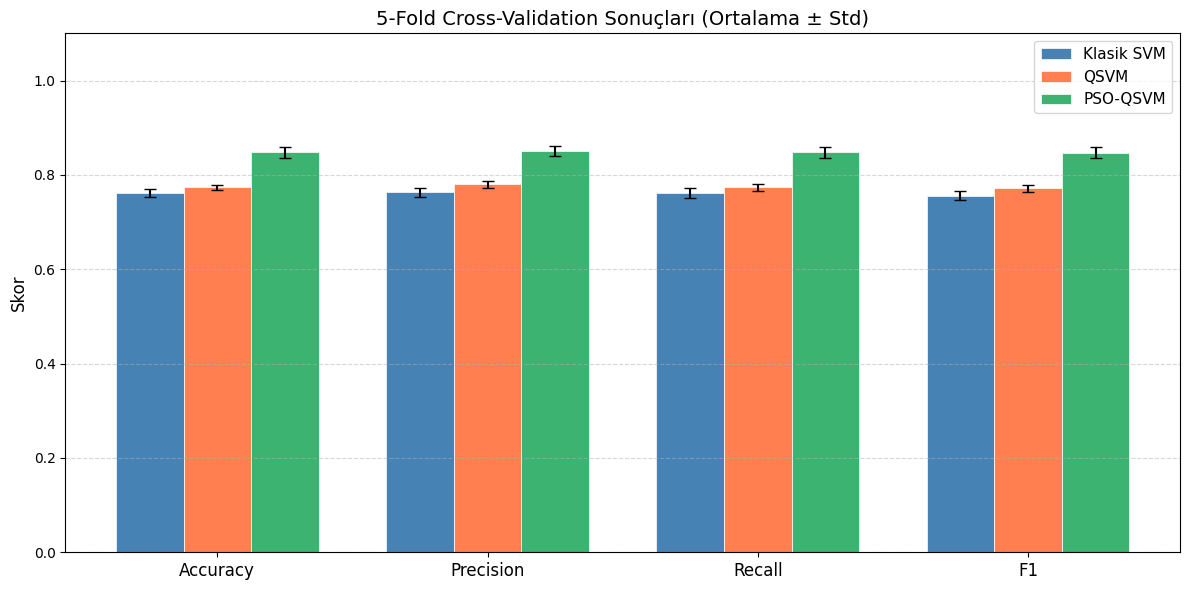

In [17]:
metrics_list = ["Accuracy", "Precision", "Recall", "F1"]
model_names  = ["Klasik SVM", "QSVM", "PSO-QSVM"]
colors       = ["steelblue", "coral", "mediumseagreen"]

means = {}
stds  = {}
for model_name, fold_list in models_data.items():
    df_f = pd.DataFrame(fold_list)
    means[model_name] = df_f.mean()
    stds[model_name]  = df_f.std()

x     = np.arange(len(metrics_list))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for idx, (model, color) in enumerate(zip(model_names, colors)):
    ax.bar(
        x + (idx - 1) * width,
        [means[model][m] for m in metrics_list],
        width,
        yerr=[stds[model][m] for m in metrics_list],
        label=model,
        color=color,
        capsize=4,
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Skor", fontsize=12)
ax.set_title("5-Fold Cross-Validation Sonuçları (Ortalama ± Std)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("kfold_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

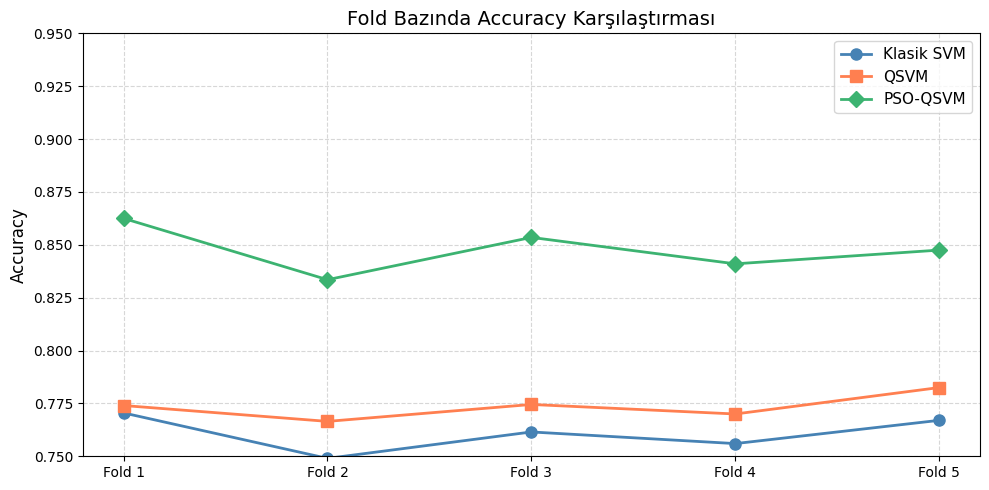

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

fold_labels = [f"Fold {i+1}" for i in range(N_SPLITS)]

for model_name, fold_list, color, marker in zip(
    model_names,
    [svm_fold_metrics, qsvm_fold_metrics, pso_fold_metrics],
    colors,
    ["o", "s", "D"],
):
    accs = [m["Accuracy"] for m in fold_list]
    ax.plot(fold_labels, accs, marker=marker, label=model_name,
            color=color, linewidth=2, markersize=8)

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Fold Bazında Accuracy Karşılaştırması", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_ylim(0.75, 0.95)

plt.tight_layout()
plt.savefig("kfold_accuracy_line.png", dpi=150, bbox_inches="tight")
plt.show()

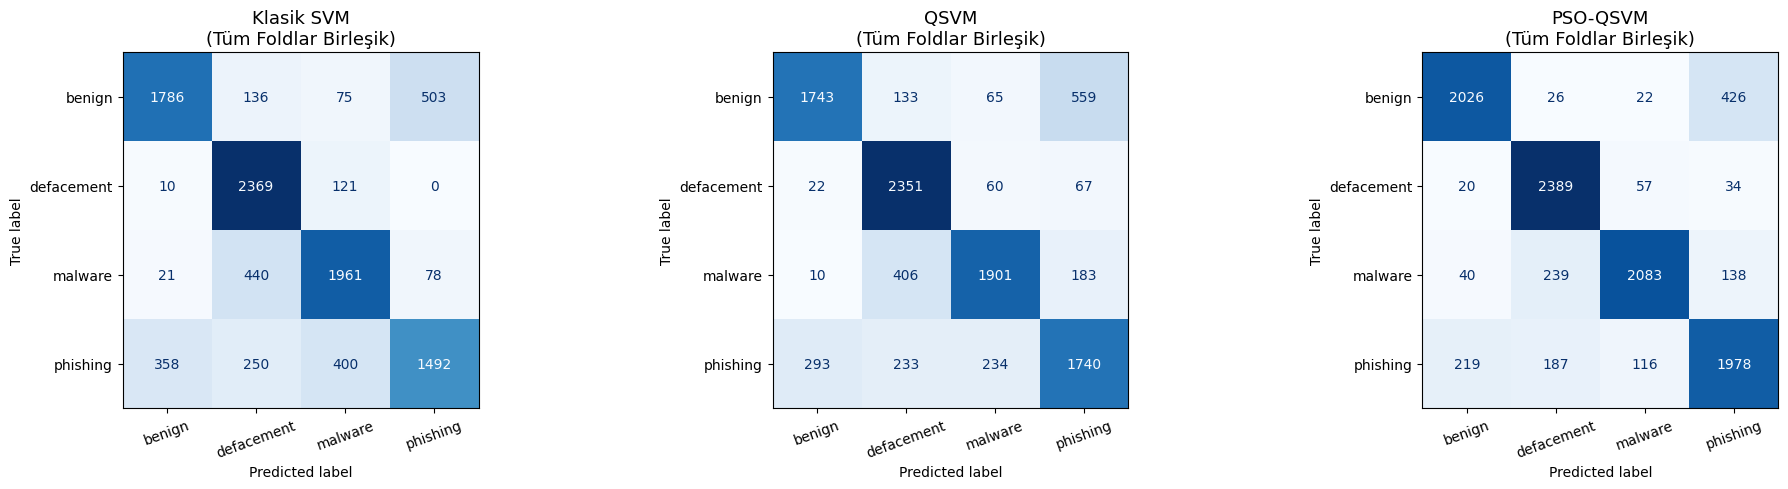

In [19]:
CLASS_NAMES = ["benign", "defacement", "malware", "phishing"]
all_preds = {
    "Klasik SVM": svm_fold_preds,
    "QSVM":       qsvm_fold_preds,
    "PSO-QSVM":   pso_fold_preds,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (model_name, preds_list) in zip(axes, all_preds.items()):
    y_true_all = np.concatenate([p[0] for p in preds_list])
    y_pred_all = np.concatenate([p[1] for p in preds_list])

    cm = confusion_matrix(y_true_all, y_pred_all)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{model_name}\n(Tüm Foldlar Birleşik)", fontsize=13)
    plt.setp(ax.get_xticklabels(), rotation=20)

plt.tight_layout()
plt.savefig("kfold_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
for model_name, preds_list in all_preds.items():
    y_true_all = np.concatenate([p[0] for p in preds_list])
    y_pred_all = np.concatenate([p[1] for p in preds_list])

    print("=" * 60)
    print(f"{model_name} — Classification Report (5-Fold Birleşik)")
    print("=" * 60)
    print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

Klasik SVM — Classification Report (5-Fold Birleşik)
              precision    recall  f1-score   support

      benign       0.82      0.71      0.76      2500
  defacement       0.74      0.95      0.83      2500
     malware       0.77      0.78      0.78      2500
    phishing       0.72      0.60      0.65      2500

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000

QSVM — Classification Report (5-Fold Birleşik)
              precision    recall  f1-score   support

      benign       0.84      0.70      0.76      2500
  defacement       0.75      0.94      0.84      2500
     malware       0.84      0.76      0.80      2500
    phishing       0.68      0.70      0.69      2500

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000

PSO-QSVM — Classification Repo

/tmp/ipykernel_18089/681564394.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


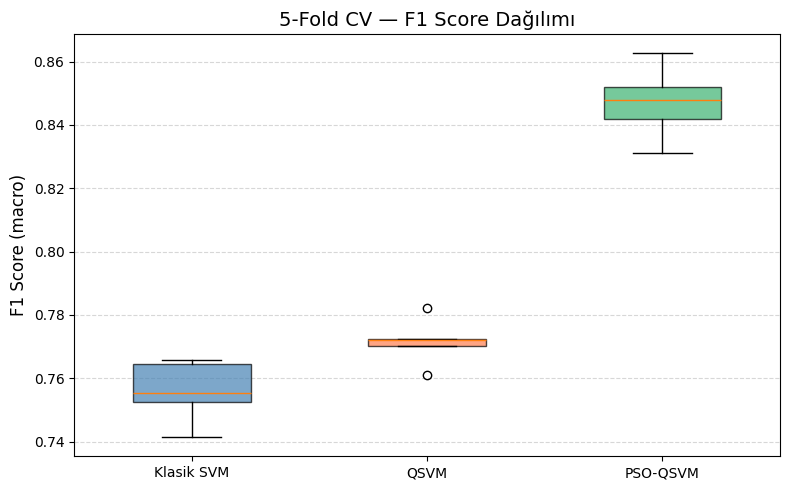

In [21]:
f1_data = {
    name: [m["F1"] for m in folds_list]
    for name, folds_list in models_data.items()
}

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    f1_data.values(),
    labels=f1_data.keys(),
    patch_artist=True,
    widths=0.5,
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("F1 Score (macro)", fontsize=12)
ax.set_title("5-Fold CV — F1 Score Dağılımı", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("kfold_f1_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
SAVE_DIR = "/content/drive/MyDrive/bitirme/data/results"  # ← kendi yolun
os.makedirs(SAVE_DIR, exist_ok=True)

# Fold bazında detaylı sonuçlar
all_fold_rows = []
for model_name, fold_list in models_data.items():
    for i, metrics in enumerate(fold_list):
        row = {"Model": model_name, "Fold": i + 1}
        row.update(metrics)
        all_fold_rows.append(row)

df_all_folds = pd.DataFrame(all_fold_rows)
df_all_folds.to_csv(os.path.join(SAVE_DIR, "kfold_detailed_results.csv"), index=False)

# Özet sonuçlar
summary_numeric = {}
for model_name, fold_list in models_data.items():
    df_f = pd.DataFrame(fold_list)
    summary_numeric[model_name] = {
        "Accuracy_mean": df_f["Accuracy"].mean(),
        "Accuracy_std":  df_f["Accuracy"].std(),
        "Precision_mean": df_f["Precision"].mean(),
        "Precision_std":  df_f["Precision"].std(),
        "Recall_mean": df_f["Recall"].mean(),
        "Recall_std":  df_f["Recall"].std(),
        "F1_mean": df_f["F1"].mean(),
        "F1_std":  df_f["F1"].std(),
    }

df_summary_num = pd.DataFrame(summary_numeric).T
df_summary_num.to_csv(os.path.join(SAVE_DIR, "kfold_summary_results.csv"))

# Tahminleri kaydet
for model_name, preds_list in all_preds.items():
    y_true_all = np.concatenate([p[0] for p in preds_list])
    y_pred_all = np.concatenate([p[1] for p in preds_list])
    safe_name  = model_name.lower().replace(" ", "_").replace("-", "_")
    np.save(os.path.join(SAVE_DIR, f"y_true_kfold_{safe_name}.npy"), y_true_all)
    np.save(os.path.join(SAVE_DIR, f"y_pred_kfold_{safe_name}.npy"), y_pred_all)

# Grafikleri de Drive'a kopyala
import shutil
for png in ["kfold_comparison_bar.png", "kfold_accuracy_line.png",
            "kfold_confusion_matrices.png", "kfold_f1_boxplot.png"]:
    if os.path.exists(png):
        shutil.copy(png, os.path.join(SAVE_DIR, png))

print("✅ Tüm sonuçlar Drive'a kaydedildi:")
print(f"   {SAVE_DIR}/")
!ls -la {SAVE_DIR}

✅ Tüm sonuçlar Drive'a kaydedildi:
   /content/drive/MyDrive/bitirme/data/results/
total 738
-rw------- 1 root root  77668 May 15 16:56 kfold_accuracy_line.png
-rw------- 1 root root  48991 May 15 16:56 kfold_comparison_bar.png
-rw------- 1 root root 105839 May 15 16:56 kfold_confusion_matrices.png
-rw------- 1 root root   1146 May 15 16:56 kfold_detailed_results.csv
-rw------- 1 root root  37444 May 15 16:56 kfold_f1_boxplot.png
-rw------- 1 root root    586 May 15 16:56 kfold_summary_results.csv
-rw------- 1 root root  80128 May 15 16:56 y_pred_kfold_klasik_svm.npy
-rw------- 1 root root  80128 May 15 16:56 y_pred_kfold_pso_qsvm.npy
-rw------- 1 root root  80128 May 15 16:56 y_pred_kfold_qsvm.npy
-rw------- 1 root root  80128 May 15 16:56 y_true_kfold_klasik_svm.npy
-rw------- 1 root root  80128 May 15 16:56 y_true_kfold_pso_qsvm.npy
-rw------- 1 root root  80128 May 15 16:56 y_true_kfold_qsvm.npy
